# PCA Artifact Analysis for `xxx`

This notebook only reads PCA artifacts under `feature_selection/pca/select_pca/`.

Use it in two modes:
- single artifact set: summarize the currently committed PCA results
- paired artifact sets: compare `with_xxx` and `without_xxx` runs side by side

Important limitation:
- the current PCA artifacts store transformed matrices, explained variance tables, PCA component names, and run metadata
- they do not store labels, row ids, predictions, or saved confusion matrices
- because of that, this notebook can compare result metrics across artifact sets, but it cannot reconstruct a new confusion matrix from artifacts alone

If you want the `xxx` comparison to work, keep two PCA artifact snapshots, for example:
- `artifacts_with_xxx/`
- `artifacts_without_xxx/`


In [1]:
from functools import lru_cache
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

print('Imports loaded.')


Imports loaded.


In [2]:
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / 'pyproject.toml').exists() else next(
    path for path in [CWD, *CWD.parents] if (path / 'pyproject.toml').exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from feature_selection.common import filter_feature_frame, resolve_pca_artifact_dir

PCA_DIR = REPO_ROOT / 'feature_selection' / 'pca' / 'select_pca'
DEFAULT_ARTIFACT_DIR = PCA_DIR / 'artifacts'
WITH_XXX_DIR = resolve_pca_artifact_dir(REPO_ROOT, include_xxx=True, use_variant_dirs=True)
WITHOUT_XXX_DIR = resolve_pca_artifact_dir(REPO_ROOT, include_xxx=False, use_variant_dirs=True)

ARTIFACT_GROUPS = {}
if WITH_XXX_DIR.exists():
    ARTIFACT_GROUPS['with_xxx'] = WITH_XXX_DIR
if WITHOUT_XXX_DIR.exists():
    ARTIFACT_GROUPS['without_xxx'] = WITHOUT_XXX_DIR
if not ARTIFACT_GROUPS and DEFAULT_ARTIFACT_DIR.exists():
    ARTIFACT_GROUPS['current'] = DEFAULT_ARTIFACT_DIR

DATASET_FILTER = None
FOCUS_DATASET = None
SAVE_COMPARISON_CSV = True

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    print(f'{group_name}: {artifact_dir} | exists={artifact_dir.exists()}')


with_xxx: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx | exists=True
without_xxx: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_without_xxx | exists=True


In [3]:
@lru_cache(maxsize=None)
def resolve_existing_source_path(source_path: str) -> Path | None:
    candidate = Path(source_path)
    if candidate.exists():
        return candidate

    parts = candidate.parts
    if 'extracted_features' in parts:
        idx = parts.index('extracted_features')
        repo_candidate = REPO_ROOT.joinpath(*parts[idx:])
        if repo_candidate.exists():
            return repo_candidate

    matches = list(REPO_ROOT.rglob(candidate.name))
    if len(matches) == 1:
        return matches[0]
    return None


@lru_cache(maxsize=None)
def load_emotion_supports(
    source_path: str,
    target_col: str,
    include_xxx: bool,
    require_agreement: bool,
    excluded_emotions: tuple[str, ...],
) -> dict[str, int]:
    path = resolve_existing_source_path(source_path)
    if path is None:
        return {}

    raw_df = pd.read_csv(path)
    filtered_df = filter_feature_frame(
        raw_df,
        target_col=target_col,
        include_xxx=include_xxx,
        require_agreement=require_agreement,
        excluded_emotions=excluded_emotions,
    )
    counts = (
        filtered_df[target_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts(dropna=False)
    )
    return {str(label): int(value) for label, value in counts.items()}


def best_metric_row(meta: dict, stage: str) -> dict:
    if stage not in {'baseline', 'pca'}:
        raise ValueError(f'Unsupported stage: {stage}')

    model_key = 'best_baseline_model' if stage == 'baseline' else 'best_pca_model'
    rows_key = 'baseline_model_metrics' if stage == 'baseline' else 'pca_model_metrics'
    best_model = meta.get(model_key)

    for row in meta.get(rows_key, []):
        if row.get('model') == best_model:
            return row

    rows = meta.get(rows_key, [])
    if rows:
        return max(rows, key=lambda row: row.get('f1_macro', float('-inf')))
    return {}


def support_columns(meta: dict) -> dict[str, int]:
    source_path = meta.get('source_path')
    if not source_path:
        return {}

    target_col = meta.get('target_col', 'emotion')
    include_xxx = bool(meta.get('include_xxx', True))
    require_agreement = bool(meta.get('require_agreement', True))
    excluded_emotions = tuple(meta.get('excluded_emotions', []))
    class_names = [str(label).strip().lower() for label in meta.get('classes', [])]
    supports = load_emotion_supports(
        str(source_path),
        target_col,
        include_xxx,
        require_agreement,
        excluded_emotions,
    )

    ordered_labels = class_names or sorted(supports)
    return {f'support_{label}': int(supports.get(label, 0)) for label in ordered_labels}


def load_group_summary(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in sorted(artifact_dir.glob('*_run_metadata.json')):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        baseline_best = best_metric_row(meta, 'baseline')
        pca_best = best_metric_row(meta, 'pca')

        row = {
            'group': group_name,
            'dataset_key': meta['dataset_key'],
            'rows_used': meta.get('rows_used'),
            'original_features': meta.get('original_features'),
            'pca_components': meta.get('pca_components_effective'),
            'variance_kept': meta.get('pca_explained_variance_total'),
            'best_baseline_model': meta.get('best_baseline_model'),
            'best_pca_model': meta.get('best_pca_model'),
            'baseline_accuracy': baseline_best.get('accuracy', meta.get('baseline_accuracy')),
            'baseline_precision_weighted': baseline_best.get('precision_weighted'),
            'baseline_recall_weighted': baseline_best.get('recall_weighted'),
            'baseline_f1_unweighted': baseline_best.get('f1_macro'),
            'pca_accuracy': pca_best.get('accuracy', meta.get('pca_accuracy')),
            'pca_precision_weighted': pca_best.get('precision_weighted'),
            'pca_recall_weighted': pca_best.get('recall_weighted'),
            'pca_f1_unweighted': pca_best.get('f1_macro'),
            'source_path': meta.get('source_path'),
        }
        row.update(support_columns(meta))
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df['accuracy_delta'] = df['pca_accuracy'] - df['baseline_accuracy']
    df['precision_weighted_delta'] = df['pca_precision_weighted'] - df['baseline_precision_weighted']
    df['recall_weighted_delta'] = df['pca_recall_weighted'] - df['baseline_recall_weighted']
    df['f1_unweighted_delta'] = df['pca_f1_unweighted'] - df['baseline_f1_unweighted']
    if DATASET_FILTER is not None:
        df = df[df['dataset_key'].isin(DATASET_FILTER)].copy()
    return df.sort_values(['group', 'pca_f1_unweighted'], ascending=[True, False], ignore_index=True)


def load_model_delta_table(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in sorted(artifact_dir.glob('*_run_metadata.json')):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        for row in meta.get('model_metric_deltas', []):
            rows.append({
                'group': group_name,
                'dataset_key': meta['dataset_key'],
                **row,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    if DATASET_FILTER is not None:
        df = df[df['dataset_key'].isin(DATASET_FILTER)].copy()
    return df


def load_variance_table(dataset_key: str, artifact_dir: Path) -> pd.DataFrame:
    path = artifact_dir / f'{dataset_key}_pca_explained_variance.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def build_pairwise_comparison(summary_df: pd.DataFrame, left_group: str, right_group: str) -> pd.DataFrame:
    left_df = summary_df[summary_df['group'] == left_group].copy()
    right_df = summary_df[summary_df['group'] == right_group].copy()

    merged = left_df.merge(
        right_df,
        on='dataset_key',
        suffixes=(f'|{left_group}', f'|{right_group}')
    )

    merged[f'pca_accuracy_change_{right_group}_minus_{left_group}'] = (
        merged[f'pca_accuracy|{right_group}'] - merged[f'pca_accuracy|{left_group}']
    )
    merged[f'pca_precision_weighted_change_{right_group}_minus_{left_group}'] = (
        merged[f'pca_precision_weighted|{right_group}'] - merged[f'pca_precision_weighted|{left_group}']
    )
    merged[f'pca_recall_weighted_change_{right_group}_minus_{left_group}'] = (
        merged[f'pca_recall_weighted|{right_group}'] - merged[f'pca_recall_weighted|{left_group}']
    )
    merged[f'pca_f1_unweighted_change_{right_group}_minus_{left_group}'] = (
        merged[f'pca_f1_unweighted|{right_group}'] - merged[f'pca_f1_unweighted|{left_group}']
    )
    merged[f'baseline_f1_unweighted_change_{right_group}_minus_{left_group}'] = (
        merged[f'baseline_f1_unweighted|{right_group}'] - merged[f'baseline_f1_unweighted|{left_group}']
    )
    merged[f'pca_delta_change_{right_group}_minus_{left_group}'] = (
        merged[f'f1_unweighted_delta|{right_group}'] - merged[f'f1_unweighted_delta|{left_group}']
    )
    return merged.sort_values(f'pca_f1_unweighted_change_{right_group}_minus_{left_group}', ascending=False, ignore_index=True)


## Artifact Summary

This section summarizes each available PCA artifact group independently.


In [4]:
summary_frames = []
delta_frames = []

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    if artifact_dir.exists():
        summary_frames.append(load_group_summary(group_name, artifact_dir))
        delta_frames.append(load_model_delta_table(group_name, artifact_dir))

summary_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
model_delta_df = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()

if summary_df.empty:
    print('No PCA artifact metadata found.')
else:
    support_cols = [col for col in summary_df.columns if col.startswith('support_')]
    summary_cols = [
        'group',
        'dataset_key',
        'rows_used',
        'original_features',
        'pca_components',
        'variance_kept',
        'best_baseline_model',
        'best_pca_model',
        'baseline_accuracy',
        'baseline_precision_weighted',
        'baseline_recall_weighted',
        'baseline_f1_unweighted',
        'pca_accuracy',
        'pca_precision_weighted',
        'pca_recall_weighted',
        'pca_f1_unweighted',
        'accuracy_delta',
        'precision_weighted_delta',
        'recall_weighted_delta',
        'f1_unweighted_delta',
    ]
    display(summary_df[summary_cols + support_cols])


,group,dataset_key,rows_used,original_features,pca_components,variance_kept,best_baseline_model,best_pca_model,baseline_accuracy,baseline_precision_weighted,baseline_recall_weighted,baseline_f1_unweighted,pca_accuracy,pca_precision_weighted,pca_recall_weighted,pca_f1_unweighted,accuracy_delta,precision_weighted_delta,recall_weighted_delta,f1_unweighted_delta,support_ang,support_exc,support_fru,support_hap,support_neu,support_sad,support_xxx
0,with_xxx,ssl_wav2vec,9887,1539,300,0.909444,logreg,logreg,0.345298,0.343552,0.345298,0.350613,0.425177,0.436312,0.425177,0.424870,0.079879,0.092760,0.079879,0.074257,1103,1041,1849,595,1708,1084,2507.0
1,with_xxx,ssl_hubert,9887,1539,300,0.933246,logreg,logreg,0.349848,0.352910,0.349848,0.351338,0.396360,0.399082,0.396360,0.398036,0.046512,0.046172,0.046512,0.046698,1103,1041,1849,595,1708,1084,2507.0
2,with_xxx,bert,9887,768,300,0.943603,random_forest,random_forest,0.416077,0.437067,0.416077,0.394244,0.403943,0.441761,0.403943,0.375506,-0.012133,0.004694,-0.012133,-0.018739,1103,1041,1849,595,1708,1084,2507.0
3,with_xxx,mfcc_normalized,9887,1150,300,0.961788,random_forest,linear_svc,0.380688,0.379866,0.380688,0.334527,0.366026,0.370314,0.366026,0.360212,-0.014661,-0.009552,-0.014661,0.025685,1103,1041,1849,595,1708,1084,2507.0
4,with_xxx,representations,9887,136,136,1.000000,random_forest,logreg,0.378665,0.366989,0.378665,0.332865,0.359454,0.371287,0.359454,0.357209,-0.019211,0.004298,-0.019211,0.024344,1103,1041,1849,595,1708,1084,2507.0
5,with_xxx,mfcc_raw,9887,1150,300,0.962062,random_forest,logreg,0.395854,0.442044,0.395854,0.353101,0.351871,0.357555,0.351871,0.353324,-0.043984,-0.084488,-0.043984,0.000223,1103,1041,1849,595,1708,1084,2507.0
6,with_xxx,prosody_energy,9887,8,8,1.000000,random_forest,random_forest,0.265420,0.252147,0.265420,0.232035,0.289181,0.270467,0.289181,0.244395,0.023761,0.018320,0.023761,0.012361,1103,1041,1849,595,1708,1084,2507.0
7,with_xxx,prosody_pitch,9887,11,11,1.000000,random_forest,random_forest,0.307887,0.298707,0.307887,0.262569,0.292720,0.275320,0.292720,0.238572,-0.015167,-0.023387,-0.015167,-0.023998,1103,1041,1849,595,1708,1084,2507.0
8,with_xxx,tfidf,216,10480,172,1.000000,linear_svc,linear_svc,0.363636,0.337380,0.363636,0.213267,0.295455,0.410973,0.295455,0.232993,-0.068182,0.073593,-0.068182,0.019726,33,5,51,4,68,11,44.0
9,with_xxx,tonality,9887,91,91,1.000000,random_forest,linear_svc,0.306876,0.302852,0.306876,0.221850,0.249747,0.260379,0.249747,0.229601,-0.057128,-0.042474,-0.057128,0.007750,1103,1041,1849,595,1708,1084,2507.0


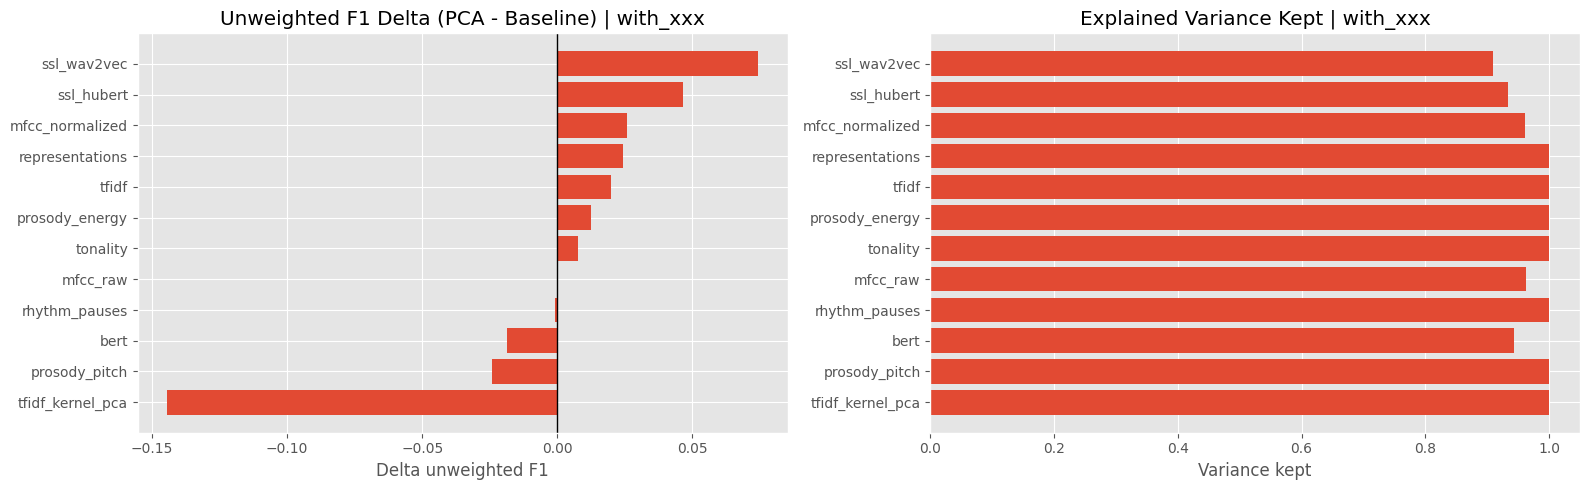

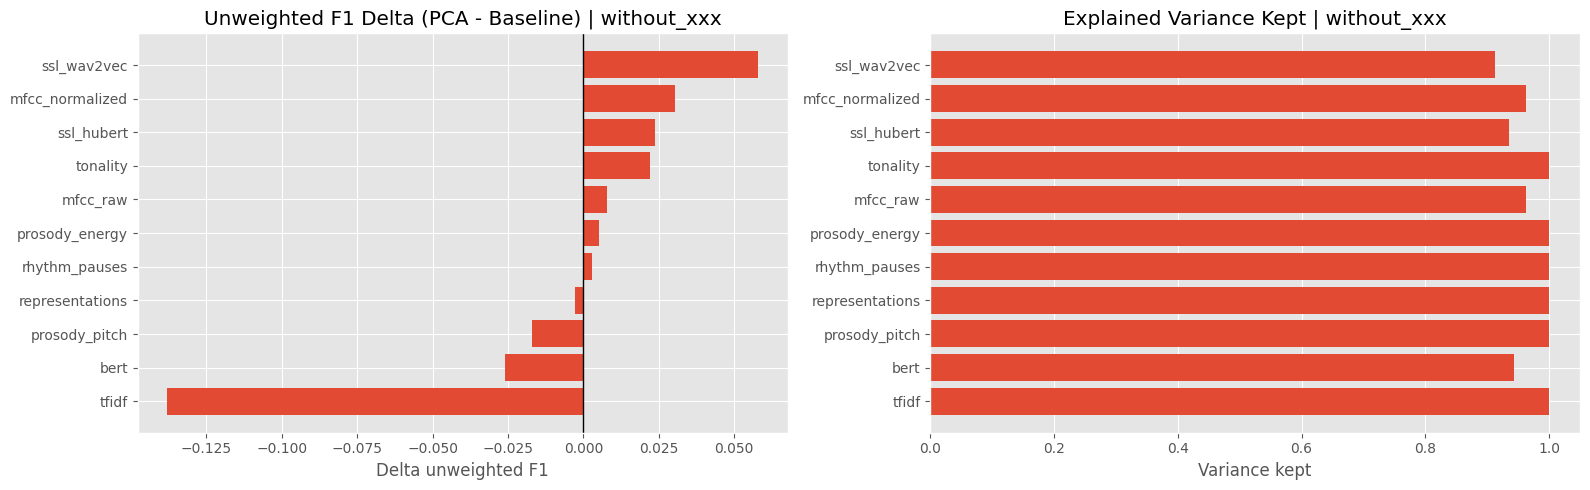

In [5]:
if not summary_df.empty:
    for group_name in summary_df['group'].unique():
        group_df = summary_df[summary_df['group'] == group_name].copy().sort_values('f1_unweighted_delta', ascending=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        axes[0].barh(group_df['dataset_key'], group_df['f1_unweighted_delta'])
        axes[0].axvline(0.0, color='black', linewidth=1)
        axes[0].set_title(f'Unweighted F1 Delta (PCA - Baseline) | {group_name}')
        axes[0].set_xlabel('Delta unweighted F1')

        axes[1].barh(group_df['dataset_key'], group_df['variance_kept'])
        axes[1].set_title(f'Explained Variance Kept | {group_name}')
        axes[1].set_xlabel('Variance kept')
        axes[1].set_xlim(0, 1.05)

        plt.tight_layout()
        plt.show()
else:
    print('No PCA artifact metadata found.')


In [6]:
if not model_delta_df.empty:
    best_per_dataset = (
        model_delta_df
        .sort_values('f1_macro_selected', ascending=False)
        .groupby(['group', 'dataset_key'], as_index=False)
        .first()
    )
    display(best_per_dataset[[
        'group',
        'dataset_key',
        'model',
        'accuracy_selected',
        'precision_weighted_selected',
        'recall_weighted_selected',
        'f1_macro_selected',
        'accuracy_delta',
        'precision_weighted_delta',
        'recall_weighted_delta',
        'f1_macro_delta',
    ]])
else:
    print('No per-model delta rows found.')


,group,dataset_key,model,accuracy_selected,precision_weighted_selected,recall_weighted_selected,f1_macro_selected,accuracy_delta,precision_weighted_delta,recall_weighted_delta,f1_macro_delta
0,with_xxx,bert,random_forest,0.403943,0.441761,0.403943,0.375506,-0.012133,0.004694,-0.012133,-0.018739
1,with_xxx,mfcc_normalized,linear_svc,0.366026,0.370314,0.366026,0.360212,0.019717,0.017857,0.019717,0.019328
2,with_xxx,mfcc_raw,logreg,0.351871,0.357555,0.351871,0.353324,0.014661,0.010999,0.014661,0.019914
3,with_xxx,prosody_energy,random_forest,0.289181,0.270467,0.289181,0.244395,0.023761,0.018320,0.023761,0.012361
4,with_xxx,prosody_pitch,random_forest,0.292720,0.275320,0.292720,0.238572,-0.015167,-0.023387,-0.015167,-0.023998
5,with_xxx,representations,logreg,0.359454,0.371287,0.359454,0.357209,0.002528,0.001715,0.002528,0.004212
6,with_xxx,rhythm_pauses,linear_svc,0.236603,0.234039,0.236603,0.203867,-0.001011,-0.004162,-0.001011,-0.000790
7,with_xxx,ssl_hubert,logreg,0.396360,0.399082,0.396360,0.398036,0.046512,0.046172,0.046512,0.046698
8,with_xxx,ssl_wav2vec,logreg,0.425177,0.436312,0.425177,0.424870,0.079879,0.092760,0.079879,0.074257
9,with_xxx,tfidf,linear_svc,0.295455,0.410973,0.295455,0.232993,-0.068182,0.073593,-0.068182,0.019726


Variance curve preview for ssl_wav2vec | group=with_xxx


,component,explained_variance_ratio,cumulative_explained_variance
0,pca_0000,0.460485,0.460485
1,pca_0001,0.066351,0.526836
2,pca_0002,0.036525,0.563361
3,pca_0003,0.026224,0.589585
4,pca_0004,0.016527,0.606112
5,pca_0005,0.013703,0.619814
6,pca_0006,0.010492,0.630306
7,pca_0007,0.009913,0.640220
8,pca_0008,0.008831,0.649051
9,pca_0009,0.008029,0.657080


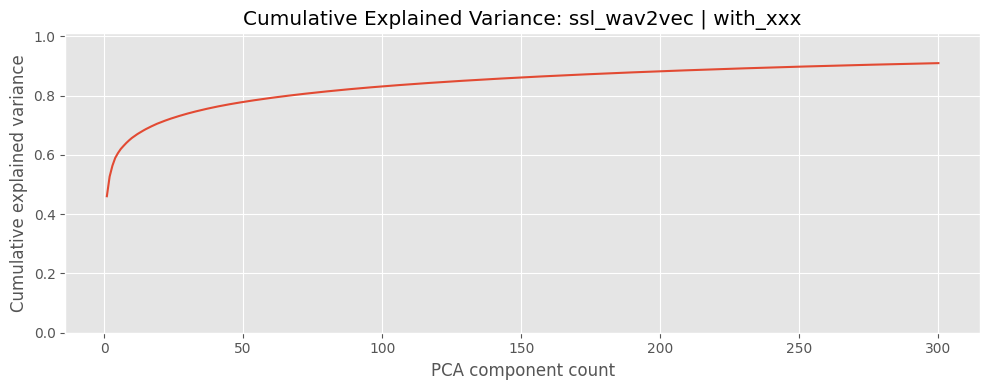

Variance curve preview for ssl_wav2vec | group=without_xxx


,component,explained_variance_ratio,cumulative_explained_variance
0,pca_0000,0.460758,0.460758
1,pca_0001,0.066754,0.527511
2,pca_0002,0.038233,0.565745
3,pca_0003,0.025676,0.591421
4,pca_0004,0.016752,0.608173
5,pca_0005,0.013607,0.621780
6,pca_0006,0.010594,0.632375
7,pca_0007,0.009896,0.642270
8,pca_0008,0.008737,0.651007
9,pca_0009,0.008018,0.659025


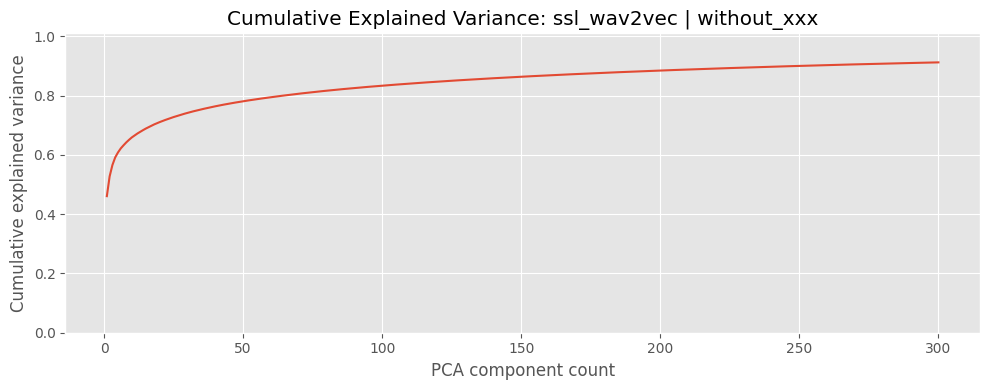

In [7]:
if not summary_df.empty:
    selected_dataset = FOCUS_DATASET or summary_df.iloc[0]['dataset_key']
    available_groups = summary_df[summary_df['dataset_key'] == selected_dataset]['group'].tolist()

    for group_name in available_groups:
        variance_df = load_variance_table(selected_dataset, ARTIFACT_GROUPS[group_name])
        print(f'Variance curve preview for {selected_dataset} | group={group_name}')
        display(variance_df.head(15))

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(range(1, len(variance_df) + 1), variance_df['cumulative_explained_variance'])
        ax.set_title(f'Cumulative Explained Variance: {selected_dataset} | {group_name}')
        ax.set_xlabel('PCA component count')
        ax.set_ylabel('Cumulative explained variance')
        ax.set_ylim(0, 1.01)
        plt.tight_layout()
        plt.show()


## `with_xxx` vs `without_xxx`

This section compares two PCA artifact groups directly.

Expected setup:
- `with_xxx`: PCA artifacts produced from a run where `xxx` was kept
- `without_xxx`: PCA artifacts produced from a run where `xxx` was excluded

If those two groups are not configured, the notebook cannot show the actual with/without difference yet.


,dataset_key,rows_used|with_xxx,rows_used|without_xxx,pca_accuracy|with_xxx,pca_accuracy|without_xxx,pca_precision_weighted|with_xxx,pca_precision_weighted|without_xxx,pca_recall_weighted|with_xxx,pca_recall_weighted|without_xxx,pca_f1_unweighted|with_xxx,pca_f1_unweighted|without_xxx,f1_unweighted_delta|with_xxx,f1_unweighted_delta|without_xxx,pca_accuracy_change_without_xxx_minus_with_xxx,pca_precision_weighted_change_without_xxx_minus_with_xxx,pca_recall_weighted_change_without_xxx_minus_with_xxx,pca_f1_unweighted_change_without_xxx_minus_with_xxx,pca_delta_change_without_xxx_minus_with_xxx
0,ssl_wav2vec,9887,7380,0.425177,0.539295,0.436312,0.541427,0.425177,0.539295,0.424870,0.519896,0.074257,0.057914,0.114118,0.105115,0.114118,0.095027,-0.016343
1,bert,9887,7380,0.403943,0.494580,0.441761,0.534668,0.403943,0.494580,0.375506,0.468160,-0.018739,-0.026118,0.090637,0.092907,0.090637,0.092655,-0.007379
2,mfcc_normalized,9887,7380,0.366026,0.466125,0.370314,0.464994,0.366026,0.466125,0.360212,0.447927,0.025685,0.030460,0.100098,0.094680,0.100098,0.087715,0.004775
3,ssl_hubert,9887,7380,0.396360,0.509485,0.399082,0.502086,0.396360,0.509485,0.398036,0.484093,0.046698,0.023905,0.113125,0.103004,0.113125,0.086058,-0.022793
4,mfcc_raw,9887,7380,0.351871,0.456640,0.357555,0.452633,0.351871,0.456640,0.353324,0.437998,0.000223,0.007898,0.104769,0.095078,0.104769,0.084675,0.007676
5,representations,9887,7380,0.359454,0.462737,0.371287,0.453987,0.359454,0.462737,0.357209,0.434412,0.024344,-0.002695,0.103283,0.082700,0.103283,0.077203,-0.027038
6,tonality,9887,7380,0.249747,0.312331,0.260379,0.335751,0.249747,0.312331,0.229601,0.293427,0.007750,0.022201,0.062583,0.075372,0.062583,0.063826,0.014450
7,prosody_energy,9887,7380,0.289181,0.350271,0.270467,0.334892,0.289181,0.350271,0.244395,0.303945,0.012361,0.005300,0.061090,0.064424,0.061090,0.059550,-0.007061
8,prosody_pitch,9887,7380,0.292720,0.355014,0.275320,0.336829,0.292720,0.355014,0.238572,0.297673,-0.023998,-0.017135,0.062294,0.061509,0.062294,0.059101,0.006863
9,rhythm_pauses,9887,7380,0.236603,0.296748,0.234039,0.275577,0.236603,0.296748,0.203867,0.241507,-0.000790,0.003020,0.060145,0.041538,0.060145,0.037640,0.003810


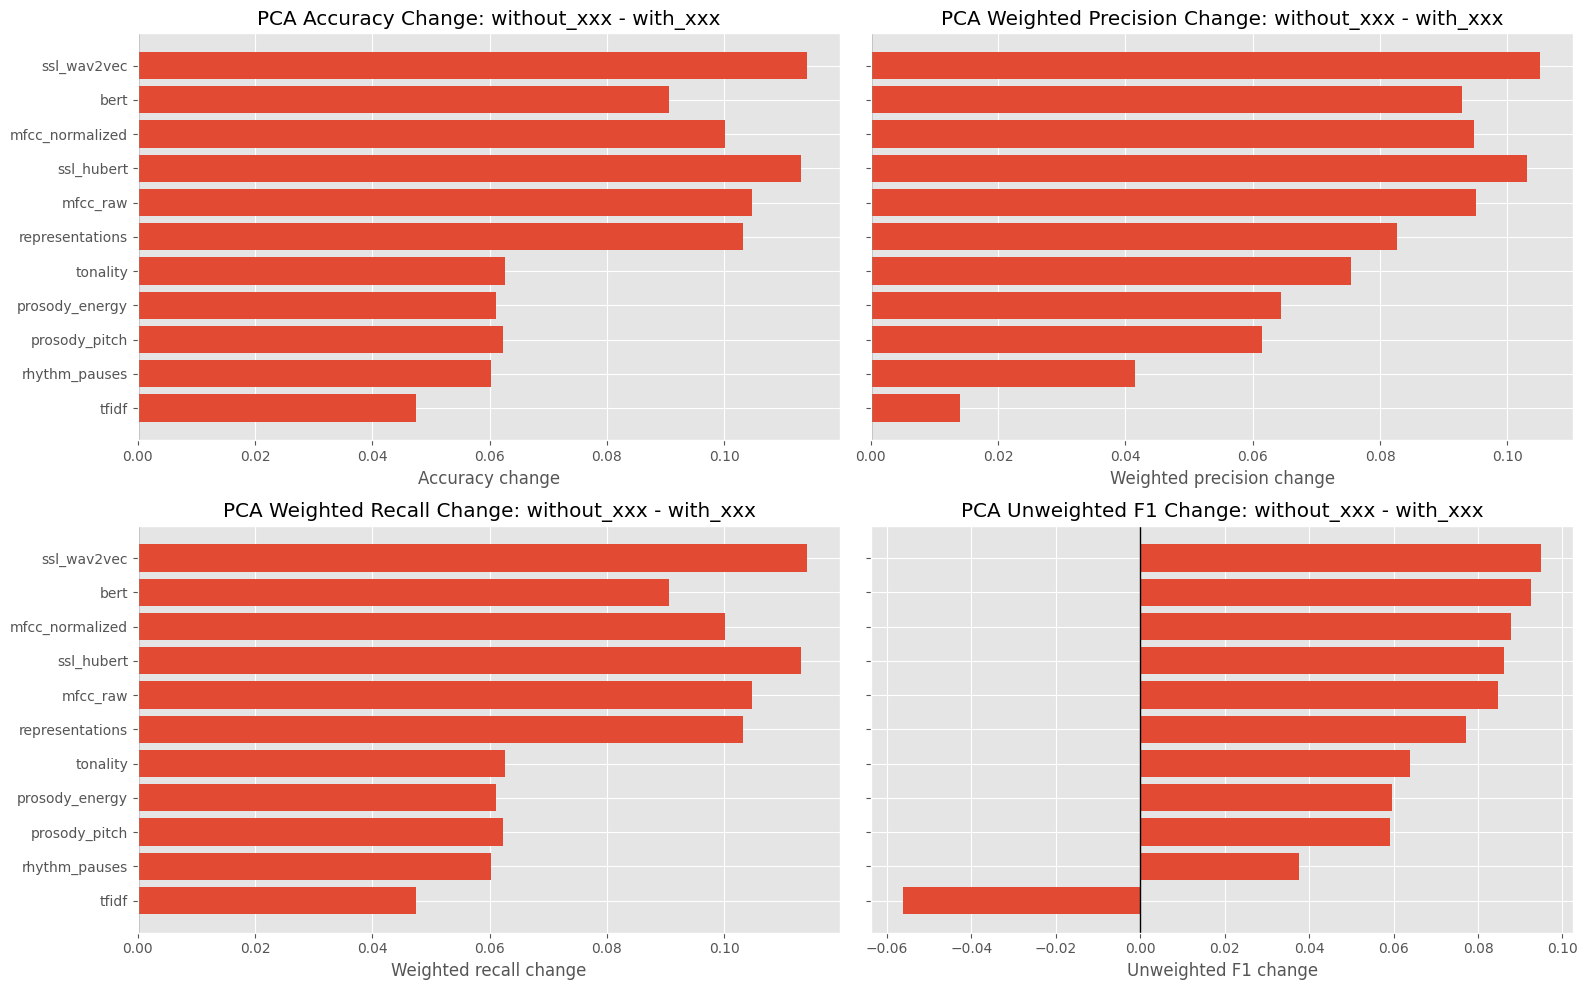

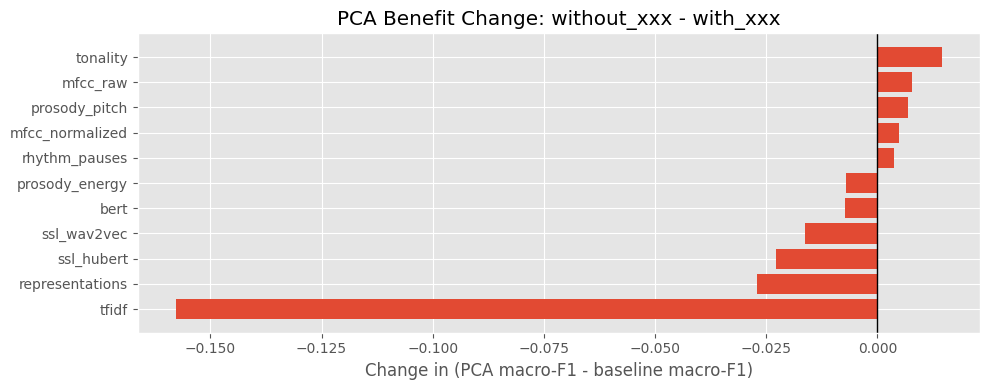

Saved comparison CSV: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts/pca_xxx_artifact_comparison.csv


In [8]:
required_groups = {'with_xxx', 'without_xxx'}
available_groups = set(summary_df['group'].unique()) if not summary_df.empty else set()

if not required_groups.issubset(available_groups):
    print('Configured artifact groups do not yet include both `with_xxx` and `without_xxx`.')
    print('Update `ARTIFACT_GROUPS` to point to two saved PCA artifact directories so this comparison can run.')
else:
    xxx_compare_df = build_pairwise_comparison(summary_df, 'with_xxx', 'without_xxx')
    display(xxx_compare_df[[
        'dataset_key',
        'rows_used|with_xxx',
        'rows_used|without_xxx',
        'pca_accuracy|with_xxx',
        'pca_accuracy|without_xxx',
        'pca_precision_weighted|with_xxx',
        'pca_precision_weighted|without_xxx',
        'pca_recall_weighted|with_xxx',
        'pca_recall_weighted|without_xxx',
        'pca_f1_unweighted|with_xxx',
        'pca_f1_unweighted|without_xxx',
        'f1_unweighted_delta|with_xxx',
        'f1_unweighted_delta|without_xxx',
        'pca_accuracy_change_without_xxx_minus_with_xxx',
        'pca_precision_weighted_change_without_xxx_minus_with_xxx',
        'pca_recall_weighted_change_without_xxx_minus_with_xxx',
        'pca_f1_unweighted_change_without_xxx_minus_with_xxx',
        'pca_delta_change_without_xxx_minus_with_xxx',
    ]])

    plot_df = xxx_compare_df.sort_values('pca_f1_unweighted_change_without_xxx_minus_with_xxx', ascending=True)

    metric_specs = [
        (
            'pca_accuracy_change_without_xxx_minus_with_xxx',
            'PCA Accuracy Change: without_xxx - with_xxx',
            'Accuracy change',
        ),
        (
            'pca_precision_weighted_change_without_xxx_minus_with_xxx',
            'PCA Weighted Precision Change: without_xxx - with_xxx',
            'Weighted precision change',
        ),
        (
            'pca_recall_weighted_change_without_xxx_minus_with_xxx',
            'PCA Weighted Recall Change: without_xxx - with_xxx',
            'Weighted recall change',
        ),
        (
            'pca_f1_unweighted_change_without_xxx_minus_with_xxx',
            'PCA Unweighted F1 Change: without_xxx - with_xxx',
            'Unweighted F1 change',
        ),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, (column, title, xlabel) in zip(axes, metric_specs):
        ax.barh(plot_df['dataset_key'], plot_df[column])
        ax.axvline(0.0, color='black', linewidth=1)
        ax.set_title(title)
        ax.set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()

    benefit_df = xxx_compare_df.sort_values('pca_delta_change_without_xxx_minus_with_xxx', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(benefit_df['dataset_key'], benefit_df['pca_delta_change_without_xxx_minus_with_xxx'])
    ax.axvline(0.0, color='black', linewidth=1)
    ax.set_title('PCA Benefit Change: without_xxx - with_xxx')
    ax.set_xlabel('Change in (PCA macro-F1 - baseline macro-F1)')

    plt.tight_layout()
    plt.show()

    if SAVE_COMPARISON_CSV:
        out_path = DEFAULT_ARTIFACT_DIR / 'pca_xxx_artifact_comparison.csv'
        xxx_compare_df.to_csv(out_path, index=False)
        print(f'Saved comparison CSV: {out_path}')
